In [3]:
import bagpy
from bagpy import bagreader
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [4]:
# file = '/home/henrypcl/rosbag/dsr_path2.bag'
file = '/Users/henrychang/DSR_s_curve_tbot_test/rosbag/dsr_path2.bag'
readbag = bagreader(file)
print(readbag.topic_table)
print(readbag.topic_table['Frequency'][0])

[INFO]  Data folder /Users/henrychang/DSR_s_curve_tbot_test/rosbag/dsr_path2 already exists. Not creating.
                       Topics                       Types  Message Count  \
0   /tbot149/april_data_multi  std_msgs/Float32MultiArray           2141   
1               /tbot149/data         geometry_msgs/Twist           2141   
2             /tbot149/l_traj  std_msgs/Float32MultiArray           2141   
3               /tbot149/odom           nav_msgs/Odometry           4686   
4             /tbot149/target         geometry_msgs/Point           2140   
5   /tbot162/april_data_multi  std_msgs/Float32MultiArray           2030   
6               /tbot162/data         geometry_msgs/Twist           2140   
7             /tbot162/l_traj  std_msgs/Float32MultiArray           2140   
8               /tbot162/odom           nav_msgs/Odometry           5234   
9             /tbot162/target         geometry_msgs/Point           2140   
10              /tbot165/odom           nav_msgs/Odometry

In [66]:
odom165_data = pd.read_csv(readbag.message_by_topic('/tbot165/odom'))
odom165_freq = readbag.topic_table['Frequency'][10]
pos_x_165 = odom165_data['pose.pose.position.x']
pos_y_165 = odom165_data['pose.pose.position.y']
head_165  = odom165_data['pose.pose.orientation.z']

odom149_data = pd.read_csv(readbag.message_by_topic('/tbot149/odom'))
odom149_freq = readbag.topic_table['Frequency'][3]
pos_x_149 = odom149_data['pose.pose.position.x']
pos_y_149 = odom149_data['pose.pose.position.y']
head_149  = odom149_data['pose.pose.orientation.z']

odom201_data = pd.read_csv(readbag.message_by_topic('/tbot201/odom'))
odom201_freq = readbag.topic_table['Frequency'][14]
pos_x_201 = odom201_data['pose.pose.position.x']
pos_y_201 = odom201_data['pose.pose.position.y']
head_201  = odom201_data['pose.pose.orientation.z']

odom162_data = pd.read_csv(readbag.message_by_topic('/tbot162/odom'))
odom162_freq = readbag.topic_table['Frequency'][8]
pos_x_162 = odom162_data['pose.pose.position.x']
pos_y_162 = odom162_data['pose.pose.position.y']
head_162  = odom162_data['pose.pose.orientation.z']

### Odom time stamp check

odom165 duration: 214.0490448474884 data length: 5656
odom149 duration: 213.97775077819824 data length: 4686
odom201 duration: 213.98371481895447 data length: 2974
odom162 duration: 214.05584478378296 data length: 5234


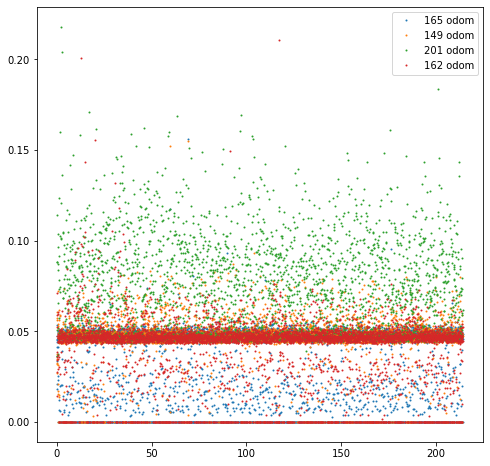

In [108]:
odom165_time = odom165_data['Time'].to_numpy()
odom165_time = odom165_time-odom165_time[0]
print('odom165 duration:', max(odom165_time)-min(odom165_time), 'data length:', len(odom165_time))

odom149_time = odom149_data['Time'].to_numpy()
odom149_time = odom149_time-odom149_time[0]
print('odom149 duration:', max(odom149_time)-min(odom149_time), 'data length:', len(odom149_time))

odom201_time = odom201_data['Time'].to_numpy()
odom201_time = odom201_time-odom201_time[0]
print('odom201 duration:', max(odom201_time)-min(odom201_time), 'data length:', len(odom201_time))

odom162_time = odom162_data['Time'].to_numpy()
odom162_time = odom162_time-odom162_time[0]
print('odom162 duration:', max(odom162_time)-min(odom162_time), 'data length:', len(odom162_time))

plt.figure(figsize=(8,8))
plt.plot(odom165_time[:-1], np.diff(odom165_time), '.', markersize='2', label='165 odom')
plt.plot(odom149_time[:-1], np.diff(odom149_time), '.', markersize='2', label='149 odom')
plt.plot(odom201_time[:-1], np.diff(odom201_time), '.', markersize='2', label='201 odom')
plt.plot(odom162_time[:-1], np.diff(odom162_time), '.', markersize='2', label='162 odom')
plt.legend()

### Plot robot trajectory

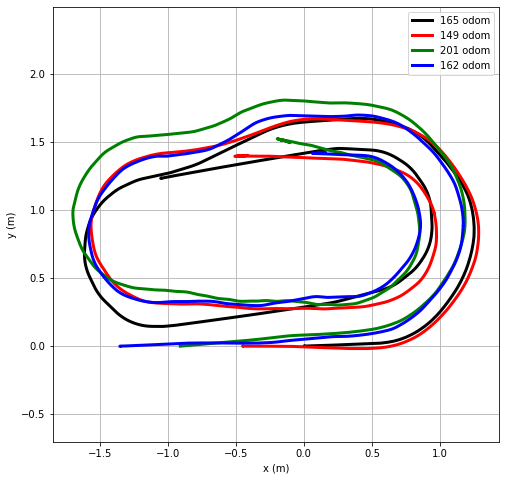

In [6]:
d = 0.45

plt.figure(figsize=(8,8))
plt.plot(pos_x_165,     pos_y_165,'k-', linewidth=3,label='165 odom')
plt.plot(pos_x_149-d,   pos_y_149,'r-', linewidth=3,label='149 odom')
plt.plot(pos_x_201-2*d, pos_y_201,'g-', linewidth=3,label='201 odom')
plt.plot(pos_x_162-3*d, pos_y_162,'b-', linewidth=3,label='162 odom')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.axis('equal')
plt.legend()
plt.grid()

### Plot relative angle

In [68]:
sensing149_data = pd.read_csv(readbag.message_by_topic('/tbot149/april_data_multi'), on_bad_lines='skip')
sensing149_freq = readbag.topic_table['Frequency'][0]
leader_phi_149  = sensing149_data['data_4'].to_numpy()


sensing201_data = pd.read_csv(readbag.message_by_topic('/tbot201/april_data_multi'), on_bad_lines='skip')
sensing201_freq = readbag.topic_table['Frequency'][11]
leader_phi_201  = sensing201_data['data_4'].to_numpy()


sensing162_data = pd.read_csv(readbag.message_by_topic('/tbot162/april_data_multi'), on_bad_lines='skip')
sensing162_freq = readbag.topic_table['Frequency'][5]
leader_phi_162  = sensing162_data['data_4'].to_numpy()



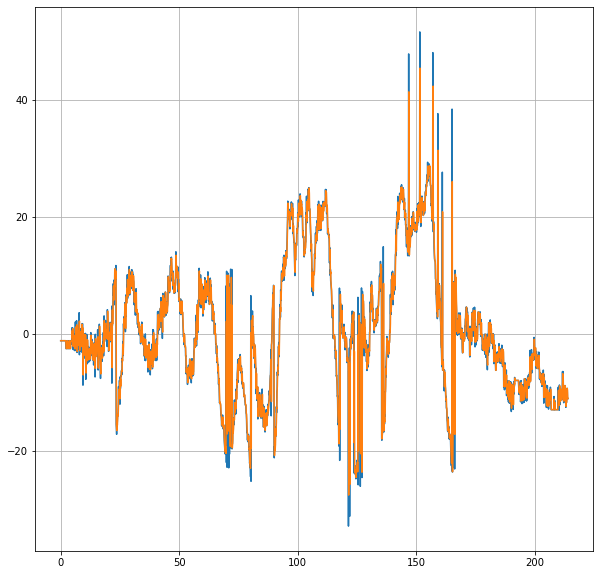

In [63]:
def lowPass(u, y_last, lowPassGain=0.2):

    return lowPassGain*u + (1-lowPassGain)*y_last 

leader_phi_149_lowpass = np.zeros(len(leader_phi_149))
leader_phi_149_last = leader_phi_149[0]
for i in range(len(leader_phi_149)):

    leader_phi_149_lowpass[i] = lowPass(leader_phi_149[i], leader_phi_149_last, lowPassGain=0.2)
    leader_phi_149_last = leader_phi_149[i]

plt.figure(figsize=(10,10))
plt.plot(np.arange(len(leader_phi_149))/sensing149_freq, leader_phi_149*180/np.pi)
plt.plot(np.arange(len(leader_phi_149))/sensing149_freq, leader_phi_149_lowpass*180/np.pi)
# plt.plot(np.arange(len(leader_phi_201))/sensing201_freq, leader_phi_201*180/np.pi)
# plt.plot(np.arange(len(leader_phi_162))/sensing162_freq, leader_phi_162*180/np.pi)
plt.grid()

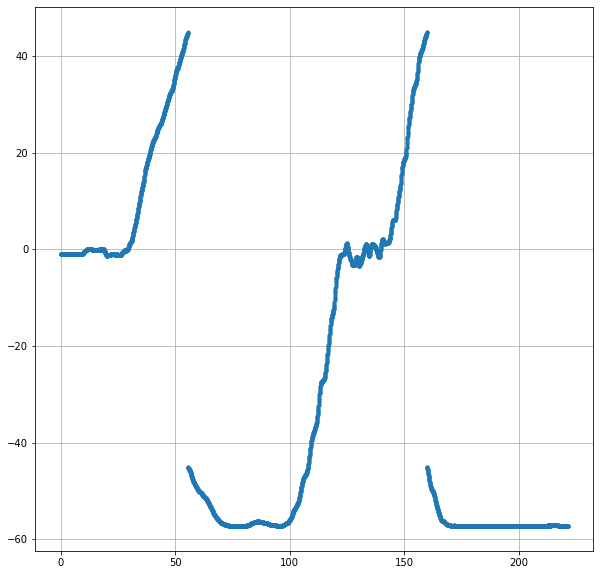

In [75]:
plt.figure(figsize=(10,10))
plt.plot(np.arange(len(head_149))/odom149_freq, head_149*180/np.pi, '.')
plt.grid()